1. Linear regression by using Deep Neural network: Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
# 1. Load Boston dataset (CSV)
data = pd.read_csv(r"D:\TE-Computer\sem VII\DL\Boston.csv")

# Features & Target
X = data.drop("medv", axis=1)   # features
y = data["medv"]                # price


In [4]:
# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [5]:
# 4. Model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 5. Compile
model.compile(optimizer='adam', loss='mse')

In [7]:
# 6. Train
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 572.7183 - val_loss: 493.9092
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 531.7495 - val_loss: 455.2314
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 489.5714 - val_loss: 411.1148
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 439.2199 - val_loss: 357.5798
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 375.6540 - val_loss: 295.5233
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 303.1734 - val_loss: 224.3992
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 222.0024 - val_loss: 157.3981
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 149.4221 - val_loss: 105.1801
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 97.0514 - val_loss: 78.1613
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 71.1287 - val_loss: 67.0743
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 58.9782 - val_loss: 58.1043
Epoch 12/100
11/11 ━━━━

In [8]:
# 7. Predict
y_pred = model.predict(X_test)

# Show first 5 results
for i in range(5):
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i][0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Actual: 24.2 Predicted: 26.785753
Actual: 19.4 Predicted: 20.479998
Actual: 39.8 Predicted: 38.156757
Actual: 20.0 Predicted: 17.153086
Actual: 20.6 Predicted: 21.55644


In [9]:
# 8. Evaluate
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 :", r2)

MSE: 10.97442404167269
R2 : 0.8827884029620454


In [10]:
# ── Step 9: Compile ───────────────────────────────────────
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

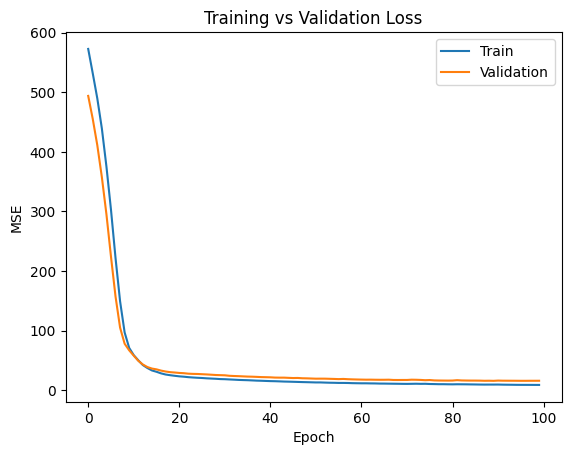

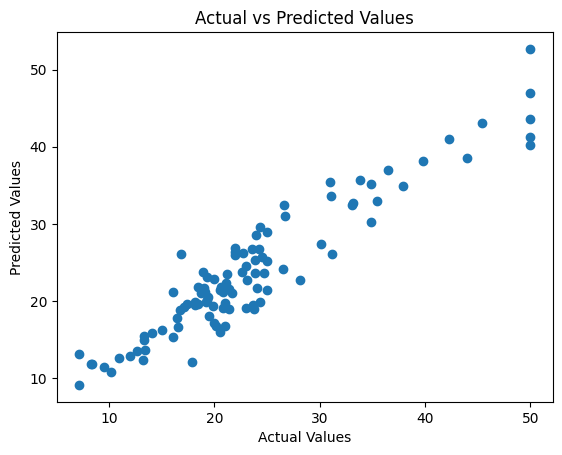

In [12]:
# ── Step 10: Plot Results ──────────────────────────────────
# 1. Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train", "Validation"])
plt.show()

# 2. Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()